# 06 GRU


Train a gated recurrent unit baseline on the normalized WESAD sequence windows.


In [20]:
from pathlib import Path
import sys

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\User\Documents\deep-learning\deep-learning


## 2. Shared training and evaluation imports


In [21]:
import json
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

from src.config import BATCH_SIZE, LEARNING_RATE, MAX_EPOCHS, PATIENCE, RANDOM_SEED, SEQUENCE_CHANNELS, WEIGHT_DECAY, WINDOW_SAMPLES
from src.helpers import count_parameters, set_seed
from src.training import (
    pos_weight_from_labels,
    save_model_artifacts,
    train_with_early_stopping,
)
from src.evaluation import (
    binary_metrics,
    collect_probabilities,
    per_subject_metrics,
    prediction_table,
    select_threshold,
)

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [22]:
# Shared setup is imported above; model architecture remains defined in this notebook.


## 3. GRU model definition


In [23]:
from src.models import GRUClassifier


## 4. Load sequence tensors


In [24]:
sequence_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
preprocessing_dir = PROJECT_ROOT / "artifacts" / "preprocessing"

X_train = torch.load(sequence_dir / "X_train.pt").float()
y_train = torch.load(sequence_dir / "y_train.pt").float()
X_validation = torch.load(sequence_dir / "X_validation.pt").float()
y_validation = torch.load(sequence_dir / "y_validation.pt").float()
X_test = torch.load(sequence_dir / "X_test.pt").float()
y_test = torch.load(sequence_dir / "y_test.pt").float()

metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")
with (preprocessing_dir / "sequence_channels.json").open("r", encoding="utf-8") as handle:
    saved_sequence_channels = json.load(handle)

assert saved_sequence_channels == SEQUENCE_CHANNELS
assert X_train.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_validation.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_test.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_validation).all()
assert torch.isfinite(X_test).all()
assert set(y_train.numpy().astype(int)).issubset({0, 1})
assert set(y_validation.numpy().astype(int)).issubset({0, 1})
assert set(y_test.numpy().astype(int)).issubset({0, 1})
assert len(metadata_train) == len(y_train)
assert len(metadata_validation) == len(y_validation)
assert len(metadata_test) == len(y_test)
assert np.array_equal(metadata_train["binary_label"].to_numpy(), y_train.numpy().astype(int))
assert np.array_equal(metadata_validation["binary_label"].to_numpy(), y_validation.numpy().astype(int))
assert np.array_equal(metadata_test["binary_label"].to_numpy(), y_test.numpy().astype(int))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_validation["subject_id"]))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))
assert set(metadata_validation["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))

X_train.shape, X_validation.shape, X_test.shape


(torch.Size([1429, 960, 6]),
 torch.Size([287, 960, 6]),
 torch.Size([426, 960, 6]))

## 5. Load window metadata


In [25]:
metadata_validation.head(), metadata_test.head()


(   window_id subject_id       split  label  binary_label  start_sample  \
 0       1429         S5  validation      1             0          8940   
 1       1430         S5  validation      1             0          9420   
 2       1431         S5  validation      1             0          9900   
 3       1432         S5  validation      1             0         10380   
 4       1433         S5  validation      1             0         10860   
 
    end_sample  start_time_seconds  end_time_seconds  
 0        9900             279.375           309.375  
 1       10380             294.375           324.375  
 2       10860             309.375           339.375  
 3       11340             324.375           354.375  
 4       11820             339.375           369.375  ,
    window_id subject_id split  label  binary_label  start_sample  end_sample  \
 0       1716         S2  test      1             0          9810       10770   
 1       1717         S2  test      1             0    

## 6. Create TensorDataset objects


In [26]:
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)


## 7. Create DataLoaders


In [27]:
train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 8. Inspect input and output shapes


In [28]:
model = GRUClassifier(input_size=X_train.shape[2]).to(device)
print(X_train[:4].shape)
print(model(X_train[:4].to(device)).shape)


torch.Size([4, 960, 6])
torch.Size([4, 1])


## 9. Define loss and optimizer


In [29]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


## 10. Train without imbalance correction


In [30]:
set_seed(42)
unweighted_model = GRUClassifier(input_size=X_train.shape[2]).to(device)
unweighted_criterion = torch.nn.BCEWithLogitsLoss()
unweighted_optimizer = torch.optim.Adam(unweighted_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
unweighted_model, unweighted_history, unweighted_training_summary = train_with_early_stopping(unweighted_model, train_loader, validation_loader, unweighted_criterion, unweighted_optimizer, device, MAX_EPOCHS, PATIENCE, gradient_clip=1.0)
unweighted_history.tail()


,epoch,train_loss,validation_loss
15,16,0.197557,0.634601
16,17,0.183649,0.624042
17,18,0.184860,0.636007
18,19,0.192646,0.684896
19,20,0.170186,0.797883


## 11. Train with class weighting


In [31]:
set_seed(42)
model = GRUClassifier(input_size=X_train.shape[2]).to(device)
pos_weight = pos_weight_from_labels(y_train, device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model, history, weighted_training_summary = train_with_early_stopping(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    gradient_clip=1.0,
)
history.tail()


,epoch,train_loss,validation_loss
11,12,0.244601,1.392428
12,13,0.266685,1.290385
13,14,0.224243,1.459341
14,15,0.253550,1.506565
15,16,0.256221,1.442553


## 12. Use early stopping


In [32]:
unweighted_validation_probabilities, unweighted_validation_true = collect_probabilities(unweighted_model, validation_loader, device)
unweighted_threshold, _ = select_threshold(unweighted_validation_true, unweighted_validation_probabilities)
unweighted_validation_metrics = binary_metrics(
    unweighted_validation_true,
    unweighted_validation_probabilities,
    unweighted_threshold,
)

weighted_validation_probabilities, weighted_validation_true = collect_probabilities(model, validation_loader, device)
weighted_threshold, _ = select_threshold(weighted_validation_true, weighted_validation_probabilities)
weighted_validation_metrics = binary_metrics(
    weighted_validation_true,
    weighted_validation_probabilities,
    weighted_threshold,
)

unweighted_best_epoch = int(unweighted_history.loc[unweighted_history["validation_loss"].idxmin(), "epoch"])
weighted_best_epoch = int(history.loc[history["validation_loss"].idxmin(), "epoch"])

validation_variant_comparison = pd.DataFrame(
    [
        {
            "method": "no_correction",
            "best_epoch": unweighted_best_epoch,
            "threshold": unweighted_threshold,
            "macro_f1": unweighted_validation_metrics["macro_f1"],
            "weighted_f1": unweighted_validation_metrics["weighted_f1"],
            "stress_precision": unweighted_validation_metrics["stress_precision"],
            "stress_recall": unweighted_validation_metrics["stress_recall"],
            "average_precision": unweighted_validation_metrics["average_precision"],
        },
        {
            "method": "class_weight",
            "best_epoch": weighted_best_epoch,
            "threshold": weighted_threshold,
            "macro_f1": weighted_validation_metrics["macro_f1"],
            "weighted_f1": weighted_validation_metrics["weighted_f1"],
            "stress_precision": weighted_validation_metrics["stress_precision"],
            "stress_recall": weighted_validation_metrics["stress_recall"],
            "average_precision": weighted_validation_metrics["average_precision"],
        },
    ]
)
display(validation_variant_comparison)

if weighted_validation_metrics["macro_f1"] >= unweighted_validation_metrics["macro_f1"]:
    selected_model = model
    selected_history = history
    selected_threshold = weighted_threshold
    selected_validation_probabilities = weighted_validation_probabilities
    selected_validation_true = weighted_validation_true
    selected_validation_metrics = weighted_validation_metrics
    selected_method = "class_weight"
    selected_best_epoch = weighted_best_epoch
    selected_training_summary = weighted_training_summary
else:
    selected_model = unweighted_model
    selected_history = unweighted_history
    selected_threshold = unweighted_threshold
    selected_validation_probabilities = unweighted_validation_probabilities
    selected_validation_true = unweighted_validation_true
    selected_validation_metrics = unweighted_validation_metrics
    selected_method = "no_correction"
    selected_best_epoch = unweighted_best_epoch
    selected_training_summary = unweighted_training_summary

model = selected_model
history = selected_history
threshold = selected_threshold
validation_probabilities = selected_validation_probabilities
validation_true = selected_validation_true
validation_metrics = {
    **selected_validation_metrics,
    "selected_imbalance_method": selected_method,
    "best_validation_epoch": selected_best_epoch,
    "variant_comparison": validation_variant_comparison.to_dict(orient="records"),
}

threshold, selected_method, validation_metrics


,method,best_epoch,threshold,macro_f1,weighted_f1,stress_precision,stress_recall,average_precision
0,no_correction,10,0.20,0.719445,0.742947,0.531915,0.872093,0.603557
1,class_weight,6,0.38,0.722161,0.752030,0.548387,0.790698,0.609475


(0.38,
 'class_weight',
 {'macro_f1': 0.7221611721611721,
  'weighted_f1': 0.7520299677094102,
  'non_stress_precision': 0.8895705521472392,
  'non_stress_recall': 0.7213930348258707,
  'stress_precision': 0.5483870967741935,
  'stress_recall': 0.7906976744186046,
  'confusion_matrix': [[145, 56], [18, 68]],
  'roc_auc': 0.7964248524817772,
  'average_precision': 0.6094745956335048,
  'selected_imbalance_method': 'class_weight',
  'best_validation_epoch': 6,
  'variant_comparison': [{'method': 'no_correction',
    'best_epoch': 10,
    'threshold': 0.2,
    'macro_f1': 0.719445467125392,
    'weighted_f1': 0.7429473461919679,
    'stress_precision': 0.5319148936170213,
    'stress_recall': 0.872093023255814,
    'average_precision': 0.6035566223809515},
   {'method': 'class_weight',
    'best_epoch': 6,
    'threshold': 0.38,
    'macro_f1': 0.7221611721611721,
    'weighted_f1': 0.7520299677094102,
    'stress_precision': 0.5483870967741935,
    'stress_recall': 0.7906976744186046,
  

## 13. Select validation threshold


In [33]:
# The previous cell selected the imbalance method and threshold using validation macro-F1.
threshold, selected_method, validation_metrics


(0.38,
 'class_weight',
 {'macro_f1': 0.7221611721611721,
  'weighted_f1': 0.7520299677094102,
  'non_stress_precision': 0.8895705521472392,
  'non_stress_recall': 0.7213930348258707,
  'stress_precision': 0.5483870967741935,
  'stress_recall': 0.7906976744186046,
  'confusion_matrix': [[145, 56], [18, 68]],
  'roc_auc': 0.7964248524817772,
  'average_precision': 0.6094745956335048,
  'selected_imbalance_method': 'class_weight',
  'best_validation_epoch': 6,
  'variant_comparison': [{'method': 'no_correction',
    'best_epoch': 10,
    'threshold': 0.2,
    'macro_f1': 0.719445467125392,
    'weighted_f1': 0.7429473461919679,
    'stress_precision': 0.5319148936170213,
    'stress_recall': 0.872093023255814,
    'average_precision': 0.6035566223809515},
   {'method': 'class_weight',
    'best_epoch': 6,
    'threshold': 0.38,
    'macro_f1': 0.7221611721611721,
    'weighted_f1': 0.7520299677094102,
    'stress_precision': 0.5483870967741935,
    'stress_recall': 0.7906976744186046,
  

## 14. Evaluate test data


In [34]:
inference_start_time = time.perf_counter()
test_probabilities, test_true = collect_probabilities(model, test_loader, device)
inference_time_seconds = time.perf_counter() - inference_start_time
test_metrics = binary_metrics(test_true, test_probabilities, threshold)
test_metrics = {**test_metrics, "inference_time_seconds": inference_time_seconds}
test_metrics


{'macro_f1': 0.37500555728448853,
 'weighted_f1': 0.46575366483344116,
 'non_stress_precision': 0.6183745583038869,
 'non_stress_recall': 0.587248322147651,
 'stress_precision': 0.13986013986013987,
 'stress_recall': 0.15625,
 'confusion_matrix': [[175, 123], [108, 20]],
 'roc_auc': 0.6150639681208054,
 'average_precision': 0.3756352285564891,
 'inference_time_seconds': 0.015901700011454523}

## 15. Evaluate each test subject


In [35]:
subject_metrics = per_subject_metrics(metadata_test, test_true, test_probabilities, threshold)
subject_metrics


,subject_id,n_windows,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,S11,144,0.468169,0.567272,0.681416,0.77,0.258065,0.181818,"[[77, 23], [36, 8]]",0.811364,0.601193
1,S14,144,0.006897,0.004215,0.000000,0.00,0.009901,0.022727,"[[0, 100], [43, 1]]",0.000000,0.174728
2,S2,138,0.651242,0.743651,0.771654,1.00,1.000000,0.275000,"[[98, 0], [29, 11]]",0.978827,0.953587


## 16. Plot training curves and confusion matrix


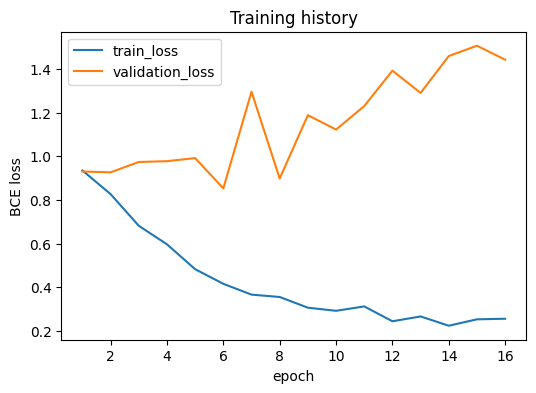

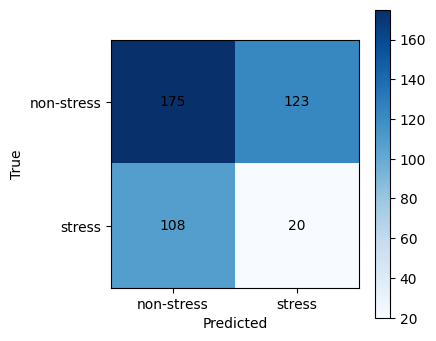

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
history.plot(x="epoch", y=["train_loss", "validation_loss"], ax=ax)
ax.set_title("Training history")
ax.set_ylabel("BCE loss")
plt.show()

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["non-stress", "stress"])
ax.set_yticks([0, 1], labels=["non-stress", "stress"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.show()


## 17. Plot ROC and precision-recall curves


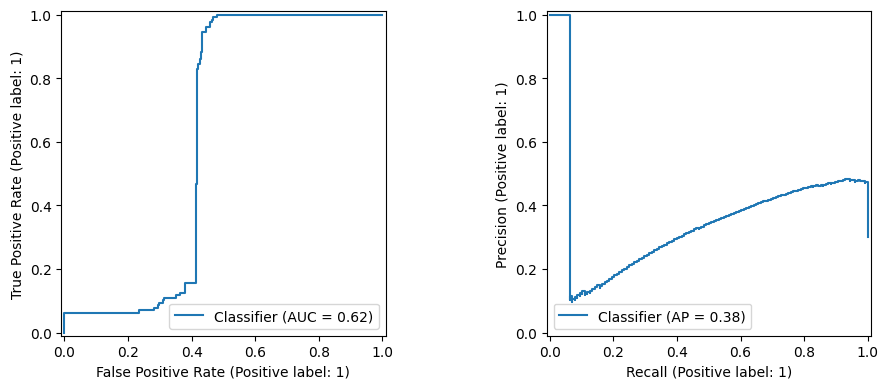

In [37]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(test_true, test_probabilities, ax=axes[0])
PrecisionRecallDisplay.from_predictions(test_true, test_probabilities, ax=axes[1])
plt.tight_layout()
plt.show()


## 18. Save model and results


In [38]:
artifact_dir = PROJECT_ROOT / "artifacts" / "models" / "gru"
test_predictions = prediction_table(metadata_test, test_true, test_probabilities, threshold)

save_model_artifacts(
    artifact_dir=artifact_dir,
    model=model,
    model_config={ "model": "GRUClassifier", "input_size": int(X_train.shape[2]), "hidden_size": 64, "dropout": 0.3,
        "parameter_count": count_parameters(model),
        "selected_imbalance_method": selected_method,
        "best_validation_epoch": selected_best_epoch,
        "random_seed": RANDOM_SEED, "uses_class_weighting": selected_method == "class_weight", "bidirectional": False },
    threshold=threshold,
    history=history,
    validation_metrics=validation_metrics,
    test_metrics=test_metrics,
    per_subject=subject_metrics,
    test_predictions=test_predictions,
    training_summary={**selected_training_summary, "selected_imbalance_method": selected_method, "inference_time_seconds": inference_time_seconds},
)
artifact_dir


WindowsPath('C:/Users/User/Documents/deep-learning/deep-learning/artifacts/models/gru')